## 1. Imports and setup

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import joblib
import json

from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, accuracy_score
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "promise_final.csv"
FIGURES_DIR = PROJECT_ROOT / "figures"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

df = pd.read_csv(DATA_PATH)
print(f"Data: {len(df)} requirements, {df['class'].nunique()} classes")
print(f"Distribution:\n{df['class'].value_counts()}")

def save_fig(name):
    for ext in ["pdf", "png"]:
        plt.savefig(FIGURES_DIR / f"{name}.{ext}", dpi=300, bbox_inches='tight')

Data: 3677 requirements, 12 classes
Distribution:
class
F     2258
SE     237
US     212
L      209
PE     163
O      157
SC      95
LF      89
PO      76
MN      75
A       71
FT      35
Name: count, dtype: int64


## 2. Train/test split

In [33]:
X = df["text"].values
y = df["class"].values
groups = df["project_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

print(f"Train: {len(X_train)} requirements from {pd.Series(groups[train_idx]).nunique()} projects")
print(f"Test:  {len(X_test)} requirements from {pd.Series(groups[test_idx]).nunique()} projects")
print(f"\nTrain distribution:\n{pd.Series(y_train).value_counts()}")
print(f"\nTest distribution:\n{pd.Series(y_test).value_counts()}")

Train: 2594 requirements from 70 projects
Test:  1083 requirements from 18 projects

Train distribution:
F     1567
SE     182
US     181
PE     133
O      119
SC      90
LF      77
PO      75
A       50
L       47
MN      41
FT      32
Name: count, dtype: int64

Test distribution:
F     691
L     162
SE     55
O      38
MN     34
US     31
PE     30
A      21
LF     12
SC      5
FT      3
PO      1
Name: count, dtype: int64


## 3. TF-IDF + SVM Pipeline

In [34]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=5000,
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        token_pattern=r"\b[a-zA-Z][a-zA-Z\-]+\b"
    )),
    ("clf", LinearSVC(
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE,
        C=1.0
    ))
])

# Train
pipeline.fit(X_train, y_train)
print("Training completed.")
print(f"Learned vocabulary size: {len(pipeline.named_steps['tfidf'].vocabulary_)}")

Training completed.
Learned vocabulary size: 5000


## 4. Binary classification pipeline

In [35]:
y_train_binary = np.where(y_train == "F", "FR", "NFR")
y_test_binary = np.where(y_test == "F", "FR", "NFR")

pipeline_binary = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2), max_features=5000,
        min_df=2, max_df=0.95, sublinear_tf=True,
        token_pattern=r"\b[a-zA-Z][a-zA-Z\-]+\b"
    )),
    ("clf", LinearSVC(
        class_weight="balanced", max_iter=2000,
        random_state=RANDOM_STATE, C=1.0
    ))
])

pipeline_binary.fit(X_train, y_train_binary)
print("Binary training completed.")

Binary training completed.


## 5. 5-fold Cross Validation

In [36]:
cv = GroupKFold(n_splits=5)

cv_results = cross_validate(
    pipeline, X_train, y_train,
    cv=cv.split(X_train, y_train, groups_train),
    scoring=["f1_macro", "f1_weighted", "accuracy"],
    n_jobs=-1
)

cv_scores_macro = cv_results["test_f1_macro"]
cv_scores_weighted = cv_results["test_f1_weighted"]
cv_scores_acc = cv_results["test_accuracy"]

print("5-fold Cross-Validation on train set:")
print(f"  F1 macro:    {cv_scores_macro.mean():.4f} ± {cv_scores_macro.std():.4f}")
print(f"  F1 weighted: {cv_scores_weighted.mean():.4f} ± {cv_scores_weighted.std():.4f}")
print(f"  Accuracy:    {cv_scores_acc.mean():.4f} ± {cv_scores_acc.std():.4f}")

5-fold Cross-Validation on train set:
  F1 macro:    0.2627 ± 0.0491
  F1 weighted: 0.5511 ± 0.0882
  Accuracy:    0.5466 ± 0.0706


## 6. Test set evaluation

In [37]:
y_pred = pipeline.predict(X_test)

f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")
acc = accuracy_score(y_test, y_pred)

print(f"TEST SET RESULTS ({len(X_test)} requirements):")
print(f"  F1 macro:    {f1_macro:.4f}")
print(f"  F1 weighted: {f1_weighted:.4f}")
print(f"  Accuracy:    {acc:.4f}")
print()
print("Detailed report per class:")
print(classification_report(y_test, y_pred, digits=3, zero_division=0))

TEST SET RESULTS (1083 requirements):
  F1 macro:    0.3112
  F1 weighted: 0.6098
  Accuracy:    0.6491

Detailed report per class:
              precision    recall  f1-score   support

           A      0.522     0.571     0.545        21
           F      0.779     0.854     0.815       691
          FT      0.000     0.000     0.000         3
           L      0.500     0.025     0.047       162
          LF      0.227     0.417     0.294        12
          MN      0.333     0.118     0.174        34
           O      0.294     0.263     0.278        38
          PE      0.317     0.667     0.430        30
          PO      0.000     0.000     0.000         1
          SC      0.059     0.200     0.091         5
          SE      0.404     0.655     0.500        55
          US      0.477     0.677     0.560        31

    accuracy                          0.649      1083
   macro avg      0.326     0.371     0.311      1083
weighted avg      0.649     0.649     0.610      1083



## 7. Binary classification test evaluation

In [38]:
y_pred_binary = pipeline_binary.predict(X_test)

print("=" * 60)
print(f"BINARY CLASSIFICATION FR vs NFR - TEST SET ({len(X_test)} reqs)")
print("=" * 60)
print(f"  F1 macro:    {f1_score(y_test_binary, y_pred_binary, average='macro'):.4f}")
print(f"  F1 weighted: {f1_score(y_test_binary, y_pred_binary, average='weighted'):.4f}")
print(f"  Accuracy:    {accuracy_score(y_test_binary, y_pred_binary):.4f}")
print()
print(classification_report(y_test_binary, y_pred_binary, digits=3))

BINARY CLASSIFICATION FR vs NFR - TEST SET (1083 reqs)
  F1 macro:    0.7079
  F1 weighted: 0.7278
  Accuracy:    0.7258

              precision    recall  f1-score   support

          FR      0.798     0.763     0.780       691
         NFR      0.612     0.661     0.636       392

    accuracy                          0.726      1083
   macro avg      0.705     0.712     0.708      1083
weighted avg      0.731     0.726     0.728      1083



## 8. Confusion matrix

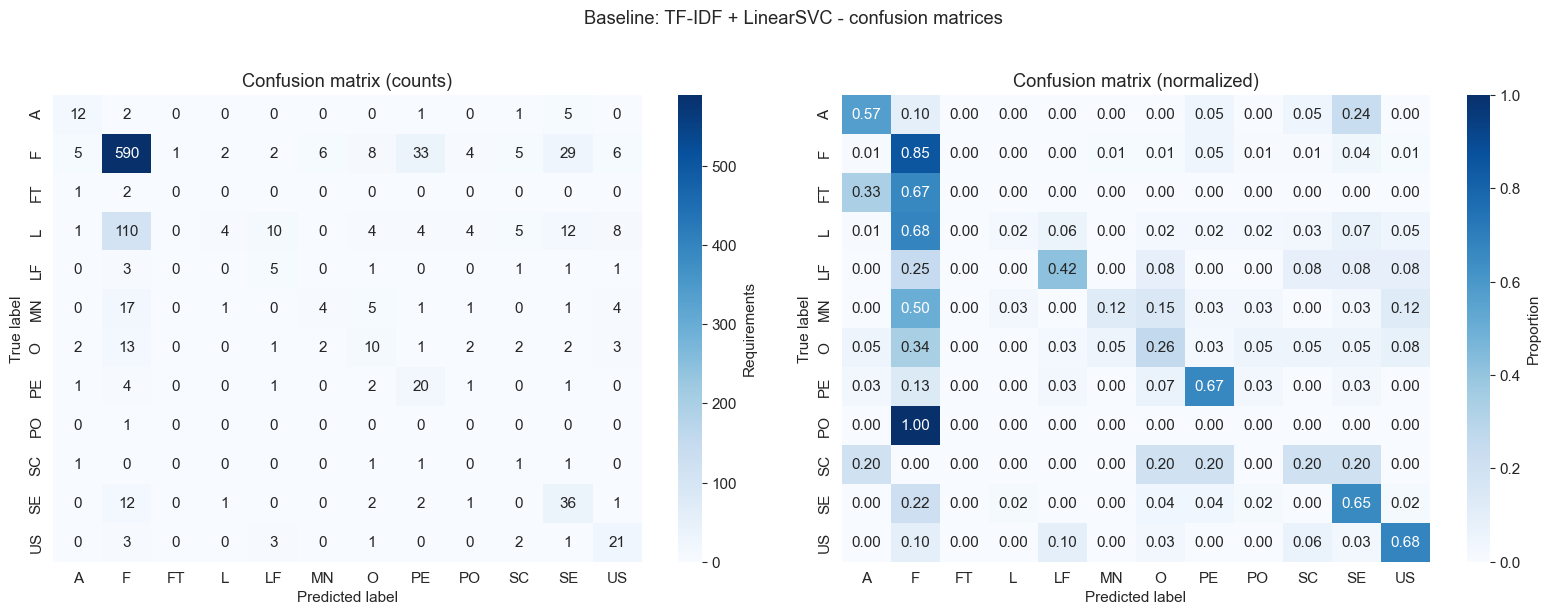

In [39]:
class_labels = sorted(df["class"].unique())
cm = confusion_matrix(y_test, y_pred, labels=class_labels)

cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels,
            ax=axes[0], cbar_kws={"label": "Requirements"})
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")
axes[0].set_title("Confusion matrix (counts)")

sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels,
            ax=axes[1], cbar_kws={"label": "Proportion"}, vmin=0, vmax=1)
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")
axes[1].set_title("Confusion matrix (normalized)")

plt.suptitle("Baseline: TF-IDF + LinearSVC - confusion matrices", y=1.02)
plt.tight_layout()
save_fig("fig_baseline_01_confusion_matrix")
plt.show()

## 9. F1 per class

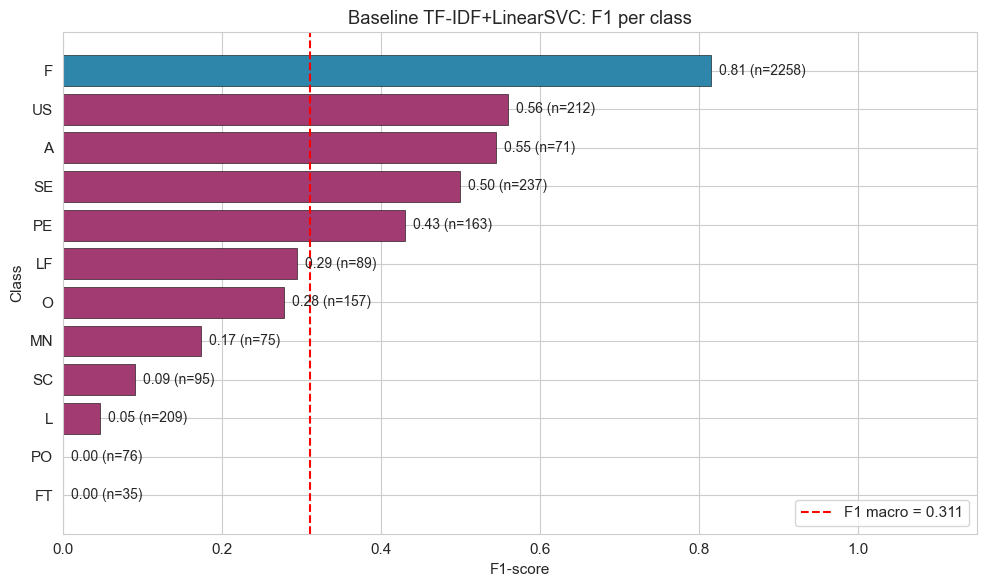

In [40]:
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
per_class = {cls: report[cls]["f1-score"] for cls in class_labels}
per_class_df = pd.Series(per_class).sort_values(ascending=True)

class_sizes = df["class"].value_counts()
sizes_sorted = class_sizes.loc[per_class_df.index]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#A23B72' if c != 'F' else '#2E86AB' for c in per_class_df.index]
bars = ax.barh(per_class_df.index, per_class_df.values, color=colors,
                edgecolor='black', linewidth=0.4)

for bar, cls, f1, size in zip(bars, per_class_df.index, per_class_df.values, sizes_sorted):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{f1:.2f} (n={size})", va='center', fontsize=10)

ax.axvline(f1_macro, color='red', linestyle='--', linewidth=1.5,
            label=f'F1 macro = {f1_macro:.3f}')
ax.set_xlabel("F1-score")
ax.set_ylabel("Class")
ax.set_title("Baseline TF-IDF+LinearSVC: F1 per class")
ax.set_xlim(0, 1.15)
ax.legend(loc='lower right')

plt.tight_layout()
save_fig("fig_baseline_02_f1_per_class")
plt.show()

## 10. Most influential words per class

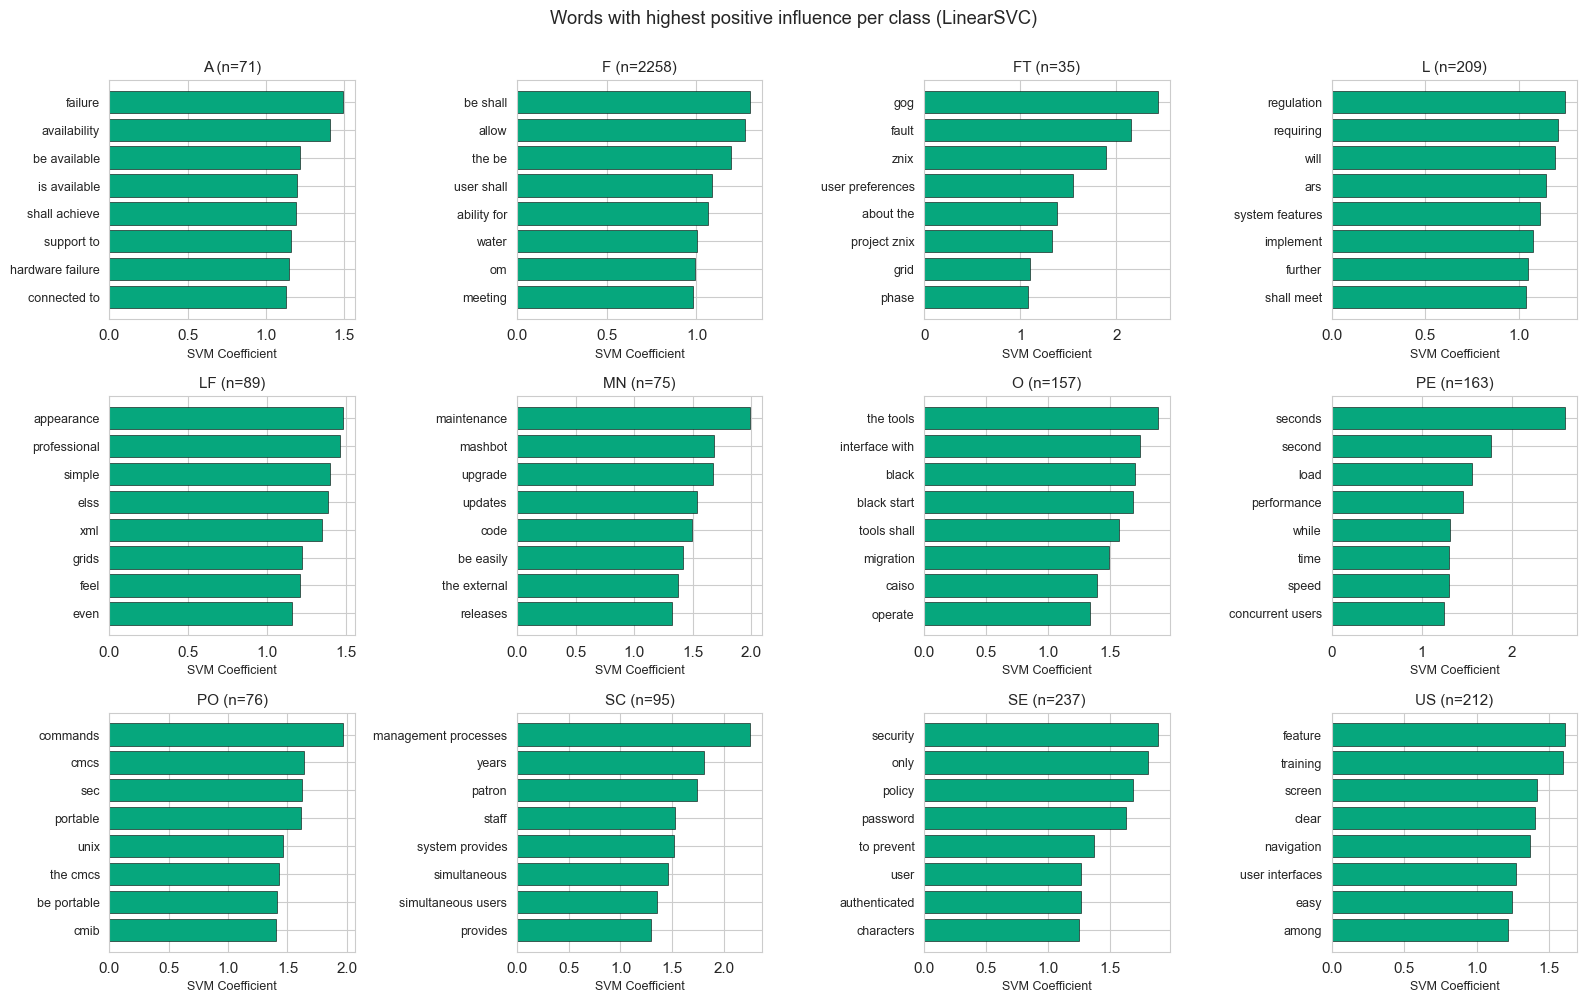

In [41]:
tfidf = pipeline.named_steps["tfidf"]
clf = pipeline.named_steps["clf"]
feature_names = tfidf.get_feature_names_out()
class_sizes = df["class"].value_counts()

n_top = 8
n_classes = len(clf.classes_)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, cls in enumerate(clf.classes_):
    coefs = clf.coef_[idx]
    top_idx = coefs.argsort()[-n_top:][::-1]
    top_words = [feature_names[i] for i in top_idx]
    top_coefs = [coefs[i] for i in top_idx]

    axes[idx].barh(range(n_top), top_coefs[::-1],
                   color='#06A77D', edgecolor='black', linewidth=0.4)
    axes[idx].set_yticks(range(n_top))
    axes[idx].set_yticklabels(top_words[::-1], fontsize=9)
    axes[idx].set_title(f"{cls} (n={class_sizes[cls]})", fontsize=11)
    axes[idx].set_xlabel("SVM Coefficient", fontsize=9)

plt.suptitle("Words with highest positive influence per class (LinearSVC)", y=1.00)
plt.tight_layout()
save_fig("fig_baseline_03_top_features")
plt.show()

## 11. Error analysis

In [42]:
mistakes = pd.DataFrame({
    "text": X_test,
    "real": y_test,
    "predicted": y_pred
})
mistakes_wrong = mistakes[mistakes["real"] != mistakes["predicted"]].copy()

print(f"Errors on test set: {len(mistakes_wrong)} / {len(X_test)} ({len(mistakes_wrong)/len(X_test)*100:.1f}%)")
print()

print("Top 10 confusions (real -> predicted):")
confusion_pairs = mistakes_wrong.groupby(["real", "predicted"]).size().sort_values(ascending=False)
print(confusion_pairs.head(10))

print("\nError examples (first 5):")
for _, row in mistakes_wrong.head(5).iterrows():
    print(f"\n  Real: {row['real']} | Predicted: {row['predicted']}")
    print(f"  Text: {row['text'][:200]}")

Errors on test set: 380 / 1083 (35.1%)

Top 10 confusions (real -> predicted):
real  predicted
L     F            110
F     PE            33
      SE            29
MN    F             17
O     F             13
SE    F             12
L     SE            12
      LF            10
F     O              8
L     US             8
dtype: int64

Error examples (first 5):

  Real: LF | Predicted: SE
  Text: The application shall match the color of the schema set forth by Department of Homeland Security

  Real: US | Predicted: F
  Text: If projected the data must be readable. On a 10x10 projection screen 90% of viewers must be able to read Event / Activity data from a viewing distance of 30

  Real: PE | Predicted: F
  Text: The product shall respond fast to keep up-to-date data in the display.

  Real: F | Predicted: PO
  Text: The system shall have a MDI form that allows for the viewing of the graph and the data table.

  Real: F | Predicted: SE
  Text: The estimator shall not apply recycled p

## 12. Model save and metrics

In [43]:
model_path_multi = MODELS_DIR / "baseline_tfidf_linsvc.joblib"
model_path_binary = MODELS_DIR / "baseline_binary_tfidf_linsvc.joblib"

joblib.dump(pipeline, model_path_multi)
joblib.dump(pipeline_binary, model_path_binary)

print(f"Multi-class model saved: {model_path_multi}")
print(f"Binary model saved:      {model_path_binary}")

metrics = {
    "multiclass": {
        "model": "TF-IDF + LinearSVC",
        "n_classes": int(df["class"].nunique()),
        "n_train": len(X_train),
        "n_test": len(X_test),
        "cv_f1_macro_mean": float(cv_scores_macro.mean()),
        "cv_f1_macro_std": float(cv_scores_macro.std()),
        "cv_f1_weighted_mean": float(cv_scores_weighted.mean()),
        "cv_accuracy_mean": float(cv_scores_acc.mean()),
        "test_f1_macro": float(f1_macro),
        "test_f1_weighted": float(f1_weighted),
        "test_accuracy": float(acc),
        "test_per_class_f1": {cls: float(per_class[cls]) for cls in per_class}
    },
    "binary": {
        "model": "TF-IDF + LinearSVC",
        "n_classes": 2,
        "test_f1_macro": float(f1_score(y_test_binary, y_pred_binary, average="macro")),
        "test_f1_weighted": float(f1_score(y_test_binary, y_pred_binary, average="weighted")),
        "test_accuracy": float(accuracy_score(y_test_binary, y_pred_binary))
    }
}

metrics_path = MODELS_DIR / "baseline_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"Metrics saved: {metrics_path}")
print(f"\nFinal scores:")
print(f"  Multi-class F1 macro: {f1_macro:.4f}")
print(f"  Binary F1 macro:      {metrics['binary']['test_f1_macro']:.4f}")

Multi-class model saved: /Users/luciano/Developer/requirements-analyzer/models/baseline_tfidf_linsvc.joblib
Binary model saved:      /Users/luciano/Developer/requirements-analyzer/models/baseline_binary_tfidf_linsvc.joblib
Metrics saved: /Users/luciano/Developer/requirements-analyzer/models/baseline_metrics.json

Final scores:
  Multi-class F1 macro: 0.3112
  Binary F1 macro:      0.7079
